# Sprint 10 - Proyecto

¡Felicidades! Completaste la sección de análisis de negocio. Es hora de aplicar el conocimiento y las habilidades que has adquirido en un proyecto: un estudio de caso analítico real que completarás por tu cuenta.

Cuando finalices el proyecto, envía tu trabajo al revisor de proyecto para su evaluación. Te dará su opinión en 24 horas. Utiliza los comentarios para realizar cambios y luego envía la nueva versión al revisor.

Es posible que recibas más comentarios sobre esta nueva versión. Esto es totalmente normal. No es nada raro que pases por varios ciclos de comentarios y revisiones.

Tu proyecto se considerará completado una vez que el revisor del proyecto lo apruebe.

## Descripción del proyecto

Lo has hecho de maravilla en el curso de TripleTen y te han ofrecido hacer prácticas en el departamento de analítica de Showz, una empresa de venta de entradas de eventos. Tu primera tarea es ayudar a optimizar los gastos de marketing.

----------------------------------

Cuentas con:

* registros del servidor con datos sobre las visitas a Showz desde enero de 2017 hasta diciembre de 2018;
* un archivo con los pedidos en este periodo;
* estadísticas de gastos de marketing.

Lo que vas a investigar:

* cómo los clientes usan el servicio;
* cuándo empiezan a comprar;
* cuánto dinero aporta cada cliente a la compañía;
* cuándo los ingresos cubren el costo de adquisición de los clientes.

## Descripción de los datos

-------------------------------------------

#### La tabla visits (registros del servidor con datos sobre las visitas al sitio web):

* Uid: identificador único del usuario.
* Device: dispositivo del usuario.
* Start Ts: fecha y hora de inicio de la sesión.
* End Ts: fecha y hora de término de la sesión.
* Source Id: identificador de la fuente de anuncios de la que proviene el usuario.

---------------------------------------

Todas las fechas de esta tabla están en formato AAAA-MM-DD.

#### La tabla orders (datos sobre pedidos):

* Uid: identificador único del usuario que realiza un pedido.
* Buy Ts: fecha y hora del pedido. Revenue: el ingreso de Showz por el pedido.

---------------------------------------

#### La tabla costs (datos sobre gastos de marketing):

* source_id: identificador de la fuente de anuncios.
* dt: fecha.
* costs: gastos en esta fuente de anuncios en este día.

### Instrucciones para completar el proyecto

#### Paso 1. Acceda los datos y prepáralos para el análisis

Almacena los datos de visitas, pedidos y gastos en variables.  Optimiza los datos para el análisis. Asegúrate de que cada columna contenga el tipo de datos correcto.
Rutas de archivos:

* /datasets/visits_log_us.csv Acceda el dataset
* /datasets/orders_log_us.csv Acceda el dataset
* /datasets/costs_us.csv Acceda el dataset



#### Paso 2. Haz informes y calcula métricas

1. Visitas:
    1. ¿Cuántas personas lo usan cada día, semana y mes?
    2. ¿Cuántas sesiones hay por día? (Un usuario puede tener más de una sesión).
    3. ¿Cuál es la duración de cada sesión?
    4. ¿Con qué frecuencia los usuarios regresan?

2. Ventas:
    1. ¿Cuándo empieza la gente a comprar? (En el análisis de KPI, generalmente nos interesa saber el tiempo que transcurre entre el registro y la conversión, es decir, cuando el usuario se convierte en cliente. Por ejemplo, si el registro y la primera compra ocurren el mismo día, el usuario podría caer en la categoría Conversion 0d. Si la primera compra ocurre al día siguiente, será Conversion 1d. Puedes usar cualquier enfoque que te permita comparar las conversiones de diferentes cohortes para que puedas determinar qué cohorte o canal de marketing es más efectivo.)
    2. ¿Cuántos pedidos hacen durante un período de tiempo dado?
    3. ¿Cuál es el tamaño promedio de compra?
    4. ¿Cuánto dinero traen? (LTV)

3. Marketing:
    1. ¿Cuánto dinero se gastó?  (Total/por fuente de adquisición/a lo largo del tiempo)
    2. ¿Cuál fue el costo de adquisición de clientes de cada una de las fuentes?
    3. ¿Cuán rentables eran las inversiones? (ROMI)

Traza gráficos para mostrar cómo difieren estas métricas para varios dispositivos y fuentes de anuncios y cómo cambian con el tiempo.

#### Paso 3. Escribe una conclusión: aconseja a los expertos de marketing cuánto dinero invertir y dónde

¿Qué fuentes/plataformas recomendarías?  Fundamenta tu selección: ¿en qué métricas te enfocaste?  ¿Por qué? ¿Qué conclusiones sacaste después de encontrar los valores métricos?

Formato: Completa la tarea en un Jupyter Notebook. Inserta el código en las celdas code y las explicaciones de texto en las celdas markdown. Aplica formato y encabezados.

# 1.0 Importación de datos y librerias

[Se procede a importar las librerias]

In [1]:
import pandas as pd
import numpy as np
from scipy import stats as st
import matplotlib.pyplot as plt
from matplotlib import pyplot as plt
import seaborn as sns
import plotly.express as px
from functools import reduce

[Se procede a importar los datos]

In [2]:
# Se cargan los datos para Notebook Jupiter de Tripleten

#df_visitas_web = pd.read_csv('/datasets/visits_log_us.csv')
#df_pedidos = pd.read_csv('/datasets/orders_log_us.csv')
#df_gastos_marketing = pd.read_csv('/datasets/costs_us.csv')

# Se cargan los datos para trabajar en Notebook

df_visitas_web = pd.read_csv('DF/visits_log_us.csv')
df_pedidos = pd.read_csv('DF/orders_log_us.csv')
df_gastos_marketing = pd.read_csv('DF/costs_us.csv')

# 2.0 Preparación de los datos

[Se procede a realizar un análisis exploratorio de los datos para corroborar el contenido y en caso de ser necesario, ordenar y depurar los mismos.]

## 2.1 Visualización inicial de los datos

[Se visualizara cada DF, limpiara y ordenara segun los datos correspondientes de manera individual:]

### 2.1.1 Visualización y limpieza del DF "df_visitas_web"

[Se visualiza la información del DF en cuestión]

In [3]:
# Se procede a visualizar la información y el contenido de las primeras 10 lineas del "df_visitas_web"

df_visitas_web.info()
print(' ')
print(' ')
print('----------------------------------------')
print(' ')
print(' ')
df_visitas_web.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Device     359400 non-null  object
 1   End Ts     359400 non-null  object
 2   Source Id  359400 non-null  int64 
 3   Start Ts   359400 non-null  object
 4   Uid        359400 non-null  uint64
dtypes: int64(1), object(3), uint64(1)
memory usage: 13.7+ MB
 
 
----------------------------------------
 
 


,Device,End Ts,Source Id,Start Ts,Uid
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168
5,desktop,2017-09-03 21:36:00,5,2017-09-03 21:35:00,16007536194108375387
6,desktop,2018-01-30 12:09:00,1,2018-01-30 11:13:00,6661610529277171451
7,touch,2017-11-05 15:15:00,3,2017-11-05 15:14:00,11423865690854540312
8,desktop,2017-07-19 10:44:00,3,2017-07-19 10:41:00,2987360259350925644
9,desktop,2017-11-08 13:43:00,5,2017-11-08 13:42:00,1289240080042562063


[Se procede a cambiar el tipo de datos en las columnas que lo amerite:]

In [4]:
# Se procede a cambiar el tipo de dato a fecha en las columnas "End Ts" y "Start Ts"

df_visitas_web['End Ts'] = pd.to_datetime(df_visitas_web['End Ts'])
df_visitas_web['Start Ts'] = pd.to_datetime(df_visitas_web['Start Ts'])

# Se procede a verificar que el cambio se haya efectuado de manera correcta:

df_visitas_web.info()
print(' ')
print(' ')
print('----------------------------------------')
print(' ')
print(' ')
df_visitas_web.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Device     359400 non-null  object        
 1   End Ts     359400 non-null  datetime64[ns]
 2   Source Id  359400 non-null  int64         
 3   Start Ts   359400 non-null  datetime64[ns]
 4   Uid        359400 non-null  uint64        
dtypes: datetime64[ns](2), int64(1), object(1), uint64(1)
memory usage: 13.7+ MB
 
 
----------------------------------------
 
 


,Device,End Ts,Source Id,Start Ts,Uid
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168
5,desktop,2017-09-03 21:36:00,5,2017-09-03 21:35:00,16007536194108375387
6,desktop,2018-01-30 12:09:00,1,2018-01-30 11:13:00,6661610529277171451
7,touch,2017-11-05 15:15:00,3,2017-11-05 15:14:00,11423865690854540312
8,desktop,2017-07-19 10:44:00,3,2017-07-19 10:41:00,2987360259350925644
9,desktop,2017-11-08 13:43:00,5,2017-11-08 13:42:00,1289240080042562063


[Se procede a cambiar los nombres de las columnas y a convertir todos los titulos de las columnas a minusculas]

In [5]:
# Se proocede a cambiar el nombre de las columnas "End Ts", "Source Id" y "Start Ts" por los nombres "End_Ts", "Source_Id" y "Start_Ts" respectivamente:

df_visitas_web.rename(columns={'End Ts': 'End_Ts', 'Source Id': 'Source_Id', 'Start Ts': 'Start_Ts'}, inplace=True)

# Se procede a cambiar los nombres de las columnas a minusculas:

df_visitas_web.columns = df_visitas_web.columns.str.lower()

# Se procede a verificar que se hayan realizado los cambios correctamente:

df_visitas_web.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   device     359400 non-null  object        
 1   end_ts     359400 non-null  datetime64[ns]
 2   source_id  359400 non-null  int64         
 3   start_ts   359400 non-null  datetime64[ns]
 4   uid        359400 non-null  uint64        
dtypes: datetime64[ns](2), int64(1), object(1), uint64(1)
memory usage: 13.7+ MB


[Se procede a verificar si existen datos duplicados:]

In [6]:
# Se verifica si existen datos duplicados:

print('Cantidad de datos duplicados:', df_visitas_web.duplicated().sum())


Cantidad de datos duplicados: 0


### 2.1.2 Visualización y limpieza del DF "df_pedidos"


[Se visualiza la información del DF en cuestión]

In [7]:
# Se procede a visualizar la información y el contenido de las primeras 10 lineas del "df_pedidos"

df_pedidos.info()
print(' ')
print(' ')
print('----------------------------------------')
print(' ')
print(' ')
df_pedidos.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   50415 non-null  object 
 1   Revenue  50415 non-null  float64
 2   Uid      50415 non-null  uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 1.2+ MB
 
 
----------------------------------------
 
 


,Buy Ts,Revenue,Uid
0,2017-06-01 00:10:00,17.00,10329302124590727494
1,2017-06-01 00:25:00,0.55,11627257723692907447
2,2017-06-01 00:27:00,0.37,17903680561304213844
3,2017-06-01 00:29:00,0.55,16109239769442553005
4,2017-06-01 07:58:00,0.37,14200605875248379450
5,2017-06-01 08:43:00,0.18,10402394430196413321
6,2017-06-01 08:54:00,1.83,12464626743129688638
7,2017-06-01 09:22:00,1.22,3644482766749211722
8,2017-06-01 09:22:00,3.30,17542070709969841479
9,2017-06-01 09:23:00,0.37,1074355127080856382


[Se procede a cambiar el tipo de datos en las columnas que lo amerite:]

In [8]:
# Se procede a cambiar el tipo de dato a fecha en las columnas "Buy Ts"

df_pedidos['Buy Ts'] = pd.to_datetime(df_pedidos['Buy Ts'])

# Se procede a verificar que el cambio se haya efectuado de manera correcta:

df_pedidos.info()
print(' ')
print(' ')
print('----------------------------------------------------')
print(' ')
print(' ')
df_pedidos.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Buy Ts   50415 non-null  datetime64[ns]
 1   Revenue  50415 non-null  float64       
 2   Uid      50415 non-null  uint64        
dtypes: datetime64[ns](1), float64(1), uint64(1)
memory usage: 1.2 MB
 
 
----------------------------------------------------
 
 


,Buy Ts,Revenue,Uid
0,2017-06-01 00:10:00,17.00,10329302124590727494
1,2017-06-01 00:25:00,0.55,11627257723692907447
2,2017-06-01 00:27:00,0.37,17903680561304213844
3,2017-06-01 00:29:00,0.55,16109239769442553005
4,2017-06-01 07:58:00,0.37,14200605875248379450
5,2017-06-01 08:43:00,0.18,10402394430196413321
6,2017-06-01 08:54:00,1.83,12464626743129688638
7,2017-06-01 09:22:00,1.22,3644482766749211722
8,2017-06-01 09:22:00,3.30,17542070709969841479
9,2017-06-01 09:23:00,0.37,1074355127080856382


[Se procede a cambiar el nombre de la columna y a convertir todos los nombres de las columnas a minusculas:]

In [9]:
# Se procede a cambiar el nombre de la columna "Buy Ts" por "Buy_Ts"

df_pedidos.rename(columns={'Buy Ts': 'Buy_Ts'}, inplace=True)

# Se procede a cambiar todos los nombres de columnas a minusculs:

df_pedidos.columns = df_pedidos.columns.str.lower()

# Se procede a verificar que se haya realizado el cambio correctamente:

df_pedidos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   buy_ts   50415 non-null  datetime64[ns]
 1   revenue  50415 non-null  float64       
 2   uid      50415 non-null  uint64        
dtypes: datetime64[ns](1), float64(1), uint64(1)
memory usage: 1.2 MB



[Se procede a verificar si existen datos duplicados:]

In [10]:
# Se verifica si existen datos duplicados:

print('Cantidad de datos duplicados:', df_pedidos.duplicated().sum())

Cantidad de datos duplicados: 0


### 2.1.3 Visualización y limpieza del DF "df_gastos_marketing"


[Se visualiza la información del DF en cuestión]

In [11]:
# Se procede a visualizar la información y el contenido de las primeras 10 lineas del "df_gastos_marketing"

df_gastos_marketing.info()
print(' ')
print(' ')
print('----------------------------------------')
print(' ')
print(' ')
df_gastos_marketing.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   source_id  2542 non-null   int64  
 1   dt         2542 non-null   object 
 2   costs      2542 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 59.7+ KB
 
 
----------------------------------------
 
 


,source_id,dt,costs
0,1,2017-06-01,75.20
1,1,2017-06-02,62.25
2,1,2017-06-03,36.53
3,1,2017-06-04,55.00
4,1,2017-06-05,57.08
5,1,2017-06-06,40.39
6,1,2017-06-07,40.59
7,1,2017-06-08,56.63
8,1,2017-06-09,40.16
9,1,2017-06-10,43.24


[Se procede a cambiar el tipo de datos en las columnas que lo amerite:]

In [12]:
# Se procede a cambiar el tipo de dato a fecha en las columnas "dt"

df_gastos_marketing['dt'] = pd.to_datetime(df_gastos_marketing['dt'])

# Se procede a verificar que el cambio se haya efectuado de manera correcta:

df_gastos_marketing.info()
print(' ')
print(' ')
print('----------------------------------------------------')
print(' ')
print(' ')
df_gastos_marketing.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   source_id  2542 non-null   int64         
 1   dt         2542 non-null   datetime64[ns]
 2   costs      2542 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 59.7 KB
 
 
----------------------------------------------------
 
 


,source_id,dt,costs
0,1,2017-06-01,75.20
1,1,2017-06-02,62.25
2,1,2017-06-03,36.53
3,1,2017-06-04,55.00
4,1,2017-06-05,57.08
5,1,2017-06-06,40.39
6,1,2017-06-07,40.59
7,1,2017-06-08,56.63
8,1,2017-06-09,40.16
9,1,2017-06-10,43.24


[Se procede a verificar si existen datos duplicados:]

In [13]:
# Se verifica si existen datos duplicados:

print('Cantidad de datos duplicados:', df_gastos_marketing.duplicated().sum())

Cantidad de datos duplicados: 0


# 3.0 Informes y calculo de métricas

Este punto esta dividido en 3 informes, los cuales para fines practicos se desglosaran de la siguiente manera:

1. Visitas;
2. Ventas;
3. Marketing.

Cada informe cuenta con sus respectivos objetivos principales, los cuales se mencionaran en cada punto de forma individual.

## 3.1 Visitas

Los objetivos a calcular son los siguietes:

1. ¿Cuántas personas lo usan cada día, semana y mes?
2. ¿Cuántas sesiones hay por día? (Un usuario puede tener más de una sesión).
3. ¿Cuál es la duración de cada sesión?
4. ¿Con qué frecuencia los usuarios regresan?

### 3.1.1 ¿Cuantas personas lo usan cada día, semana y mes?

[Se procede a obtener las metricas de DAU, WAU y MAU]

In [14]:
# Primero se procede a crear las columnas "session_year", "session_month", "session_week" y "session_date", con el metodo "isocalendar()" en el DF "df_visitas_web"

df_visitas_web['session_year'] = df_visitas_web['start_ts'].dt.isocalendar().year
df_visitas_web['session_month'] = df_visitas_web['start_ts'].dt.month
df_visitas_web['session_week'] = df_visitas_web['start_ts'].dt.isocalendar().week
df_visitas_web['session_date'] = df_visitas_web['start_ts'].dt.date

# Ahora se calcularan las metricas "DAU", "WAU" y "MAU"

DAU = df_visitas_web.groupby('session_date').agg({'uid': 'nunique'}).mean()
WAU = df_visitas_web.groupby(['session_year', 'session_week']).agg({'uid': 'nunique'}).mean()
MAU = df_visitas_web.groupby(['session_year', 'session_month']).agg({'uid': 'nunique'}).mean()

# Obtenidas las metricas, se procede a imprimirlas:

print('¿Cuantas personas lo usan cada día, semana y mes?')
print(' ')
print('A continuación se mostrara las metricas de DAU, WAU y MAU respectivamente para responder esta pregunta:')
print(' ')
print('Esta cantidad de personas lo usan diario:', int(DAU))
print('Esta cantidad de personas lo usan semanalmente:', int(WAU))
print('Esta cantidad de personas lo usan mensualmente:', int(MAU))

¿Cuantas personas lo usan cada día, semana y mes?
 
A continuación se mostrara las metricas de DAU, WAU y MAU respectivamente para responder esta pregunta:
 
Esta cantidad de personas lo usan diario: 907
Esta cantidad de personas lo usan semanalmente: 5716
Esta cantidad de personas lo usan mensualmente: 23228


/tmp/ipykernel_94591/2514953744.py:20: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print('Esta cantidad de personas lo usan diario:', int(DAU))
/tmp/ipykernel_94591/2514953744.py:21: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print('Esta cantidad de personas lo usan semanalmente:', int(WAU))
/tmp/ipykernel_94591/2514953744.py:22: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print('Esta cantidad de personas lo usan mensualmente:', int(MAU))


### 3.1.2 ¿Cuántas sesiones hay por día? (Un usuario puede tener más de una sesión).

[Se procede a crear un DF llamado "df_sesiones_por_usuario" para tener un mayor control sobre los datos y poder así obtener esta y futuras metricas]

In [15]:
# Se procede a crear el DF "df_sesiones_por_usuario" incluyendo las columnas "session_year", "session_month", "session_week" y "session_date" del DF "df_visitas_web" usando la columna "uid"

df_sesiones_por_usuario = df_visitas_web.groupby(['session_year', 'session_month', 'session_week', 'session_date']).agg({'uid': ['count', 'nunique']})

# Se crean las columnas "n_session", "n_users" y "sessions_per_user"

df_sesiones_por_usuario.columns = ['n_session', 'n_users']
df_sesiones_por_usuario['sessions_per_user'] = (df_sesiones_por_usuario['n_session'] / df_sesiones_por_usuario['n_users'])

# Se obtiene las sesiones por día:

sessions_per_day = df_sesiones_por_usuario.groupby(['session_year', 'session_month', 'session_week', 'session_date']).agg({'n_session': 'sum'})

print('¿Cuántas sesiones hay por día?')
print(' ')
print('A continuación se mostrara la cantidad de sesiones por día:')
print(' ')
print('Las sesiones por día son las siguientes:', sessions_per_day)

¿Cuántas sesiones hay por día?
 
A continuación se mostrara la cantidad de sesiones por día:
 
Las sesiones por día son las siguientes:                                                       n_session
session_year session_month session_week session_date           
2017         6             22           2017-06-01          664
                                        2017-06-02          658
                                        2017-06-03          477
                                        2017-06-04          510
                           23           2017-06-05          893
...                                                         ...
2018         5             21           2018-05-27          672
                           22           2018-05-28         1156
                                        2018-05-29         1035
                                        2018-05-30         1410
                                        2018-05-31         2256

[364 rows x 1 columns]


### 3.1.3 ¿Cuál es la duración de cada sesión?

[Se procede a calcular la duración promedio de cada sesión.]

In [16]:
# Se calcula la duración de cada sesión en segundos y se guarda en una nueva columna.
df_visitas_web['session_duration_sec'] = (df_visitas_web['end_ts'] - df_visitas_web['start_ts']).dt.total_seconds()

# Se filtra las sesiones donde la duración es menor o igual a cero (sesiones instantáneas o con errores de tiempo)
df_visitas_web = df_visitas_web[df_visitas_web['session_duration_sec'] > 0].copy()

# Convertir la duración de la sesión a minutos para una mejor interpretación
df_visitas_web['session_duration_min'] = df_visitas_web['session_duration_sec'] / 60

# Se calcula la duración promedio de la sesión
average_session_duration = df_visitas_web['session_duration_min'].mean()

print('¿Cuál es la duración de cada sesión?')
print(' ')
print(f'La duración promedio de cada sesión es de {average_session_duration:.2f} minutos.')

¿Cuál es la duración de cada sesión?
 
La duración promedio de cada sesión es de 11.90 minutos.


[Para fines de analisís, se procede a obtener el ASL para así graficarlo]

El ASL es el siguiente: 714.1695158279873


<Axes: >

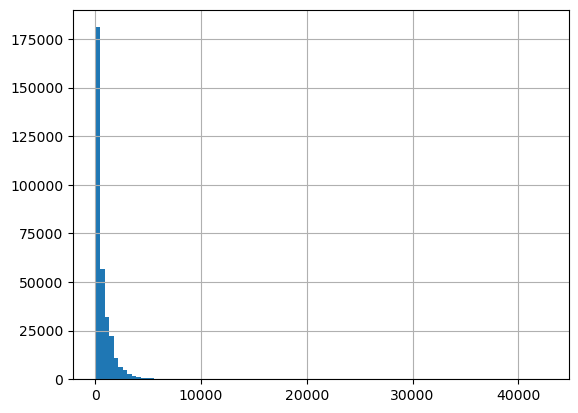

In [17]:
# Encontremos el ASL calculando la duración de todas las sesiones y encontrando la media:

df_visitas_web['session_duration_sec'] = (df_visitas_web['end_ts'] - df_visitas_web['start_ts']).dt.total_seconds()
print('El ASL es el siguiente:', df_visitas_web['session_duration_sec'].mean())


# Se procede a graficar la distribución:

df_visitas_web['session_duration_sec'].hist(bins=100)

### 3.1.4 ¿Con qué frecuencia los usuarios regresan?

[Se procede a calcular la frecuencia con la que regresan los usuarios]

In [18]:
# Se procede a calcular la frecuencía con la que los usuarios regresan al mes y a la semana:

sticky_factor_m = DAU/MAU
sticky_factor_w = DAU/WAU

print('¿Con qué frecuencia los usuarios regresan al mes?')
print(' ')
print(' ')
print(f'La frecuencia con la que los usuarios regresan al mes es de: {sticky_factor_m.iloc[0]:.5f}')
print(' ')
print(' ')
print('¿Con qué frecuencia los usuarios regresan a la semana?')
print(' ')
print(' ')
print(f'La frecuencia con la que los usuarios regresan a la semana es de: {sticky_factor_w.iloc[0]:.5f}')

¿Con qué frecuencia los usuarios regresan al mes?
 
 
La frecuencia con la que los usuarios regresan al mes es de: 0.03909
 
 
¿Con qué frecuencia los usuarios regresan a la semana?
 
 
La frecuencia con la que los usuarios regresan a la semana es de: 0.15884


## 3.1.5 Conclusiones del punto 3.1 Visitas:

Un punto relevante a resaltar es el patron de comportamiento del usuario, mas especificamente, el que esta relacionado con la retención de los usuarios.

Si bien el tiempo promedió en el que los usuarios se mantienen en el sitio es moderadamente alto (11 minutos), cabe resaltar que se esta teniendo un fallo en lograr que los usuarios regresen al sitio.

Mientras que a la semana el 15% de los usuarios vuelven a visitar la pagina, solo menos del 4% regresa en el mes. Por tal motivo se tiene que revisar mas adelante cual es la conversión de pedidos y la estrategía de marketing para poder determinar los accionables necesarios al momento ya sea de reconfigurar el sitio web, reconfigurar la estrategíade marketing o ver si va mas enfocado al tema de calidad del producto y atención al cliente.

## 3.2 Ventas

Los objetivos a calcular son los siguietes:

1. ¿Cuándo empieza la gente a comprar? (En el análisis de KPI, generalmente nos interesa saber el tiempo que transcurre entre el registro y la conversión, es decir, cuando el usuario se convierte en cliente. Por ejemplo, si el registro y la primera compra ocurren el mismo día, el usuario podría caer en la categoría Conversion 0d. Si la primera compra ocurre al día siguiente, será Conversion 1d. Puedes usar cualquier enfoque que te permita comparar las conversiones de diferentes cohortes para que puedas determinar qué cohorte o canal de marketing es más efectivo.)
2. ¿Cuántos pedidos hacen durante un período de tiempo dado?
3. ¿Cuál es el tamaño promedio de compra?
4. ¿Cuánto dinero traen? (LTV)

### 3.2.1 ¿Cuando empieza la gente a comprar?

[Se procedera a realizar los accionables correspondientes para poder realizar el analisis tal como es requerido en el proyecto:]

#### Descripción general del punto 3.2.1

En el análisis de KPI, generalmente nos interesa saber el tiempo que transcurre entre el registro y la conversión, es decir, cuando el usuario se convierte en cliente. Por ejemplo, si el registro y la primera compra ocurren el mismo día, el usuario podría caer en la categoría Conversion 0d. Si la primera compra ocurre al día siguiente, será Conversion 1d. Puedes usar cualquier enfoque que te permita comparar las conversiones de diferentes cohortes para que puedas determinar qué cohorte o canal de marketing es más efectivo.

Accionables arealizar:

1. Determinar la fecha de la primera visita de cada usuario desde `df_visitas_web`.
2. Determinar la fecha de la primera compra de cada usuario desde `df_pedidos`.
3. Combinar estas fechas para cada usuario y calcular el tiempo transcurrido entre su primera visita y su primera compra.
4. Analizar y visualizar el "tiempo de conversión" para identificar patrones o cohortes, asegurándose de que las visualizaciones tengan leyendas claras.

##### 3.2.1.1 Preparación de Datos de Primera Visita

[Obtener la fecha de la primera visita para cada usuario (uid) del DataFrame df_visitas_web.]

In [19]:
# Se creara un nuevo DF con nombre "df_primera_visita" en donde se agrupara por la columna 'uid' del DF "df_visitas_web", encontrando el valor minimo de 'start_ts' para cada grupo:

df_primera_visita = df_visitas_web.groupby('uid')['start_ts'].min().reset_index()
df_primera_visita.rename(columns={'start_ts': 'first_visit_ts'}, inplace=True)

# Se procede a mostrar los datos del nuevo DF junto con las primeras 5 filas del mismo:

print('\nInformación del DataFrame df_primera_visita:')
df_primera_visita.info()
print(' ')
print(' ')
print('----------------------')
print(' ')
print(' ')
print('Primeras 5 filas del DataFrame df_primera_visita:')
print(df_primera_visita.head())



Información del DataFrame df_primera_visita:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 207051 entries, 0 to 207050
Data columns (total 2 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   uid             207051 non-null  uint64        
 1   first_visit_ts  207051 non-null  datetime64[ns]
dtypes: datetime64[ns](1), uint64(1)
memory usage: 3.2 MB
 
 
----------------------
 
 
Primeras 5 filas del DataFrame df_primera_visita:
               uid      first_visit_ts
0   11863502262781 2018-03-01 17:27:00
1   49537067089222 2018-02-06 15:55:00
2  297729379853735 2017-06-07 18:47:00
3  313578113262317 2017-09-18 22:49:00
4  325320750514679 2017-09-30 14:29:00


##### 3.2.1.2 Preparación de Datos de Primera Compra


[Se agrupara el DataFrame 'df_pedidos' por 'uid' y luego encontraré el valor mínimo 'buy_ts' para cada grupo]

In [20]:
# Se procede a generar el nuevo DF con el nombre "df_primera_compra"

df_primera_compra = df_pedidos.groupby('uid')['buy_ts'].min().reset_index()
df_primera_compra.rename(columns={'buy_ts': 'first_purchase_ts'}, inplace=True)

# Se procede a mostrar los datos del nuevo DF junto con las primeras 5 filas del mismo:

print('\nInformación del DataFrame df_primera_compra:')
df_primera_compra.info()
print(' ')
print(' ')
print('----------------------')
print(' ')
print(' ')
print('Primeras 5 filas del DataFrame df_primera_compra:')
print(df_primera_compra.head())


Información del DataFrame df_primera_compra:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36523 entries, 0 to 36522
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   uid                36523 non-null  uint64        
 1   first_purchase_ts  36523 non-null  datetime64[ns]
dtypes: datetime64[ns](1), uint64(1)
memory usage: 570.8 KB
 
 
----------------------
 
 
Primeras 5 filas del DataFrame df_primera_compra:
                uid   first_purchase_ts
0   313578113262317 2018-01-03 21:51:00
1  1575281904278712 2017-06-03 10:13:00
2  2429014661409475 2017-10-11 18:33:00
3  2464366381792757 2018-01-28 15:54:00
4  2551852515556206 2017-11-24 10:14:00


##### 3.2.1.3 Calculo de tiempo transcurrido entre primera visita y primera compra


[Se procede a fusionar los dos DF previamente generados para realizar el calculo]

In [21]:
# Se procede a fusionar los DF:

df_conversion_time = df_primera_visita.merge(df_primera_compra, on='uid', how='inner')
df_conversion_time['time_to_conversion'] = df_conversion_time['first_purchase_ts'] - df_conversion_time['first_visit_ts']

# Se procede a calcular el tiempo en días:

df_conversion_time['time_to_conversion_days'] = df_conversion_time['time_to_conversion'].dt.days

# Se imprime la información del nuevo DF junto con las primeras 5 filas:

print('\nInformación del DataFrame df_conversion_time:')
df_conversion_time.info()
print(' ')
print(' ')
print('----------------------')
print(' ')
print(' ')
print('Primeras 5 filas del DataFrame df_conversion_time:')
print(df_conversion_time.head())

# Se imprime las estadisticas:
print(' ')
print(' ')
print('----------------------')
print(' ')
print(' ')
print('\nEstadísticas descriptivas para time_to_conversion_days:')
print(df_conversion_time['time_to_conversion_days'].describe())


Información del DataFrame df_conversion_time:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36081 entries, 0 to 36080
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype          
---  ------                   --------------  -----          
 0   uid                      36081 non-null  uint64         
 1   first_visit_ts           36081 non-null  datetime64[ns] 
 2   first_purchase_ts        36081 non-null  datetime64[ns] 
 3   time_to_conversion       36081 non-null  timedelta64[ns]
 4   time_to_conversion_days  36081 non-null  int64          
dtypes: datetime64[ns](2), int64(1), timedelta64[ns](1), uint64(1)
memory usage: 1.4 MB
 
 
----------------------
 
 
Primeras 5 filas del DataFrame df_conversion_time:
                uid      first_visit_ts   first_purchase_ts  \
0   313578113262317 2017-09-18 22:49:00 2018-01-03 21:51:00   
1  1575281904278712 2017-06-03 10:13:00 2017-06-03 10:13:00   
2  2429014661409475 2017-10-11 17:14:00 2017-10-11 1

[Cabe resaltar que en las estadísticas descriptivas de `time_to_conversion_days` se observaron valores negativos. Esto no es posible, ya que una compra no puede realizarse antes de la primera visita. Al presentarse una discrepancía, se procedera a realizar los movimientos necesarios para corregirla.]

Los pasos a seguir seran, filtrar las filas donde el valor de time_to_conversion_days sea negativo. Posteriormente, se recalculara las estadísticas descriptivas.

In [22]:
# Se procede a realizar la labor del filtrado:

df_conversion_time_filtered = df_conversion_time[df_conversion_time['time_to_conversion_days'] >= 0].copy()

# Se imprime el DF con la corrección realizada:

print('\nInformación del DataFrame df_conversion_time_filtered:')
df_conversion_time_filtered.info()
print(' ')
print(' ')
print('----------------------')
print(' ')
print(' ')
print('Primeras 5 filas del DataFrame df_conversion_time_filtered después de limpiar valores negativos:')
print(df_conversion_time_filtered.head())

# Se procede a imprimer el estadistico actualizado:

print(' ')
print(' ')
print('----------------------')
print(' ')
print(' ')
print('\nEstadísticas descriptivas para time_to_conversion_days después de limpiar valores negativos:')
print(df_conversion_time_filtered['time_to_conversion_days'].describe())


Información del DataFrame df_conversion_time_filtered:
<class 'pandas.core.frame.DataFrame'>
Index: 35886 entries, 0 to 36080
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype          
---  ------                   --------------  -----          
 0   uid                      35886 non-null  uint64         
 1   first_visit_ts           35886 non-null  datetime64[ns] 
 2   first_purchase_ts        35886 non-null  datetime64[ns] 
 3   time_to_conversion       35886 non-null  timedelta64[ns]
 4   time_to_conversion_days  35886 non-null  int64          
dtypes: datetime64[ns](2), int64(1), timedelta64[ns](1), uint64(1)
memory usage: 1.6 MB
 
 
----------------------
 
 
Primeras 5 filas del DataFrame df_conversion_time_filtered después de limpiar valores negativos:
                uid      first_visit_ts   first_purchase_ts  \
0   313578113262317 2017-09-18 22:49:00 2018-01-03 21:51:00   
1  1575281904278712 2017-06-03 10:13:00 2017-06-03 10:13:00   
2 

[Se utilizara un histograma para comprender la distribución de "tiempo_hasta_días_de_conversión" e identificar patrones de conversión. Así a su vez, se calculara la media y la mediana para resumir la tendencia central del tiempo de conversión:]


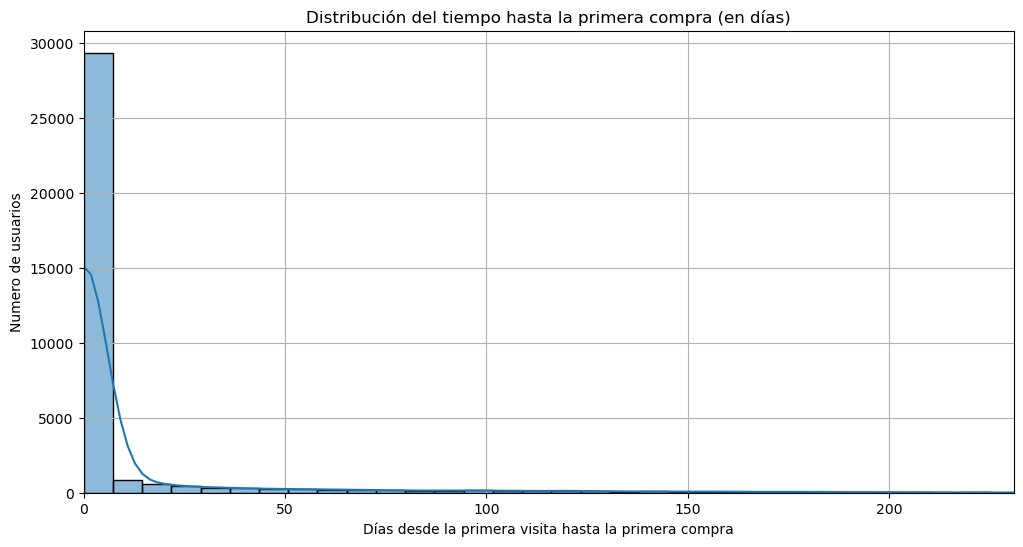

 
 
----------------------
 
 
Tiempo promedio hasta la primera compra: 15.58 días
 
 
----------------------
 
 
Mediana de tiempo hasta la primera compra: 0.00 días


In [23]:
plt.figure(figsize=(12, 6))
sns.histplot(df_conversion_time_filtered['time_to_conversion_days'], bins=50, kde=True)
plt.title('Distribución del tiempo hasta la primera compra (en días)')
plt.xlabel('Días desde la primera visita hasta la primera compra')
plt.ylabel('Numero de usuarios')
plt.xlim(0, df_conversion_time_filtered['time_to_conversion_days'].quantile(0.99)) # Limit x-axis to 99th percentile for better visualization
plt.grid(True)
plt.show()

mean_conversion_time = df_conversion_time_filtered['time_to_conversion_days'].mean()
median_conversion_time = df_conversion_time_filtered['time_to_conversion_days'].median()

print(' ')
print(' ')
print('----------------------')
print(' ')
print(' ')
print(f'Tiempo promedio hasta la primera compra: {mean_conversion_time:.2f} días')
print(' ')
print(' ')
print('----------------------')
print(' ')
print(' ')
print(f'Mediana de tiempo hasta la primera compra: {median_conversion_time:.2f} días')


##### 3.2.1.4 Análisis de Conversión por Cohorte

[Se analizara las conversiones en función del tiempo transcurrido desde la primera visita, categorizando a los usuarios en cohortes de conversión y visualizando su distribución:]

Se procedera a realizar un analisis de cohorte calculando para cada usuario en df_conversion_time_filtered, su mes de adquisición a partir de first_visit_ts, luego se combinara esta información con df_pedidos para asociar cada pedido con su cohorte de adquisición y, finalmente, se estara calculando el tiempo de vida del cohorte para cada pedido encontrando la diferencia en meses entre la fecha de compra y el mes de adquisición.

[Se procede a determinar el mes de adquisición para cada usuario a partir de su primera visita.]


In [24]:
# Se procede a crear una copia de las columnas relevantes en el nuevo DF
first_order_date_by_customers = df_conversion_time_filtered[['uid', 'first_visit_ts', 'first_purchase_ts', 'time_to_conversion_days']].copy()

# Se procede a crear la columna 'acquisition_month' como un objeto de Período para facilitar el análisis de cohorte
first_order_date_by_customers['acquisition_month'] = first_order_date_by_customers['first_visit_ts'].dt.to_period('M')

# Se procede a mostrar la info del DF con las primeras 5 lineas
print('\nInformación del DataFrame first_order_date_by_customers:')
first_order_date_by_customers.info()
print(' ')
print(' ')
print('------------------------------------')
print(' ')
print('Primeras 5 filas del DataFrame first_order_date_by_customers con la nueva columna acquisition_month:')
print(first_order_date_by_customers.head())


Información del DataFrame first_order_date_by_customers:
<class 'pandas.core.frame.DataFrame'>
Index: 35886 entries, 0 to 36080
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   uid                      35886 non-null  uint64        
 1   first_visit_ts           35886 non-null  datetime64[ns]
 2   first_purchase_ts        35886 non-null  datetime64[ns]
 3   time_to_conversion_days  35886 non-null  int64         
 4   acquisition_month        35886 non-null  period[M]     
dtypes: datetime64[ns](2), int64(1), period[M](1), uint64(1)
memory usage: 1.6 MB
 
 
------------------------------------
 
Primeras 5 filas del DataFrame first_order_date_by_customers con la nueva columna acquisition_month:
                uid      first_visit_ts   first_purchase_ts  \
0   313578113262317 2017-09-18 22:49:00 2018-01-03 21:51:00   
1  1575281904278712 2017-06-03 10:13:00 2017-06-03 10:13:00 

[Para evitar SettingWithCopyWarning y que el Df sea modificado o cause error de manera accidental mas adelante, se creara explícitamente una copia de las columnas seleccionadas del df_conversion_time_filtered y luego le agregaré la columna acquisition_month.]



In [25]:
# Se procede a crear una copia de las columnas relevantes en el nuevo DF
first_order_date_by_customers = df_conversion_time_filtered[['uid', 'first_visit_ts', 'first_purchase_ts', 'time_to_conversion_days']].copy()

# Se procede a crear la columna 'acquisition_month' como un objeto de Período para facilitar el análisis de cohorte
first_order_date_by_customers['acquisition_month'] = first_order_date_by_customers['first_visit_ts'].dt.to_period('M')

# Se procede a mostrar la info del DF con las primeras 5 lineas
first_order_date_by_customers.info()
print(' ')
print(' ')
print('------------------------------------')
print(' ')
print('Primeras 5 filas del DataFrame first_order_date_by_customers con la nueva columna acquisition_month:')
print(first_order_date_by_customers.head())

<class 'pandas.core.frame.DataFrame'>
Index: 35886 entries, 0 to 36080
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   uid                      35886 non-null  uint64        
 1   first_visit_ts           35886 non-null  datetime64[ns]
 2   first_purchase_ts        35886 non-null  datetime64[ns]
 3   time_to_conversion_days  35886 non-null  int64         
 4   acquisition_month        35886 non-null  period[M]     
dtypes: datetime64[ns](2), int64(1), period[M](1), uint64(1)
memory usage: 1.6 MB
 
 
------------------------------------
 
Primeras 5 filas del DataFrame first_order_date_by_customers con la nueva columna acquisition_month:
                uid      first_visit_ts   first_purchase_ts  \
0   313578113262317 2017-09-18 22:49:00 2018-01-03 21:51:00   
1  1575281904278712 2017-06-03 10:13:00 2017-06-03 10:13:00   
2  2429014661409475 2017-10-11 17:14:00 2017-10-11 18:3

[Una vez identificado el mes de adquisición de cada usuario, se fusionara con el DF de df_pedidos para así, asociar cada pedido con la cohorte de adquisición del usuario:]



In [26]:
# Se procede a fusionar los DF

df_orders_cohort = df_pedidos.merge(first_order_date_by_customers[['uid', 'acquisition_month']], on='uid', how='left')

# Se procede a mostrar la info del nuevo DF y las primeras 5 filas:

print('\nInformación del DataFrame df_orders_cohort:')
df_orders_cohort.info()
print(' ')
print(' ')
print('------------------------------------')
print(' ')
print(' ')
print('Primeras 5 filas del DataFrame df_orders_cohort después de la fusión:')
print(df_orders_cohort.head())



Información del DataFrame df_orders_cohort:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   buy_ts             50415 non-null  datetime64[ns]
 1   revenue            50415 non-null  float64       
 2   uid                50415 non-null  uint64        
 3   acquisition_month  49324 non-null  period[M]     
dtypes: datetime64[ns](1), float64(1), period[M](1), uint64(1)
memory usage: 1.5 MB
 
 
------------------------------------
 
 
Primeras 5 filas del DataFrame df_orders_cohort después de la fusión:
               buy_ts  revenue                   uid acquisition_month
0 2017-06-01 00:10:00    17.00  10329302124590727494           2017-06
1 2017-06-01 00:25:00     0.55  11627257723692907447           2017-06
2 2017-06-01 00:27:00     0.37  17903680561304213844           2017-06
3 2017-06-01 00:29:00     0.55  16

[Se procede a convertir la columna 'buy_ts' en df_orders_cohort a un período mensual y luego restar 'acquisition_month' para obtener la diferencia en meses. Pero primero se eliminara las filas donde acquisition_month sea NaT, ya que estos pedidos no se pueden vincular a una cohorte de adquisición, y por ultimo se procedera a calcular el cohort_lifetime:]


In [27]:
# Se procede a convertir ´buy_ts'en un periodo mensual:

df_orders_cohort['order_month'] = df_orders_cohort['buy_ts'].dt.to_period('M')

# Se procede a eliminar filas donde acquisition_month es NaT antes de calcular cohort_lifetime

df_orders_cohort = df_orders_cohort.dropna(subset=['acquisition_month']).copy()

# Se procede a calcular el 'cohort_lifetime'

df_orders_cohort['cohort_lifetime'] = (df_orders_cohort['order_month'] - df_orders_cohort['acquisition_month']).apply(lambda x: x.n)

# Se procede a mostrar la info del DF junto a las primeras 5 lineas
print('\nInformación del DataFrame df_orders_cohort después de añadir cohort_lifetime:')
df_orders_cohort.info()
print(' ')
print(' ')
print('------------------------------------')
print(' ')
print(' ')
print('Primeras 5 filas del DataFrame df_orders_cohort con la nueva columna cohort_lifetime:')
print(df_orders_cohort.head())



Información del DataFrame df_orders_cohort después de añadir cohort_lifetime:
<class 'pandas.core.frame.DataFrame'>
Index: 49324 entries, 0 to 50414
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   buy_ts             49324 non-null  datetime64[ns]
 1   revenue            49324 non-null  float64       
 2   uid                49324 non-null  uint64        
 3   acquisition_month  49324 non-null  period[M]     
 4   order_month        49324 non-null  period[M]     
 5   cohort_lifetime    49324 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(1), period[M](2), uint64(1)
memory usage: 2.6 MB
 
 
------------------------------------
 
 
Primeras 5 filas del DataFrame df_orders_cohort con la nueva columna cohort_lifetime:
               buy_ts  revenue                   uid acquisition_month  \
0 2017-06-01 00:10:00    17.00  10329302124590727494           2017-06   
1 201

### 3.2.2 ¿Cuántos pedidos hacen durante un período de tiempo dado? y ¿Cuál es el tamaño promedio de compra?

#### 3.2.2.1 Tabla Pivote: Número de Pedidos por Cohorte y Tiempo

[Se procede a crear una segunda tabla pivote similar a la anterior, pero donde los valores sean el número total de pedidos (count de uid o revenue) realizados por cada cohorte en cada mes de su vida.]

Se procedera a realizar los siguientes pasos:

1. Generar la tabla dinámica que muestra la cantidad de pedidos por vida útil de cohorte, agrupando así el DataFrame df_orders_cohort por acquisition_month y cohort_lifetime

2. Se contara la cantidad de pedidos en cada grupo y luego se procedera a desapilar el cohort_lifetime para crear las columnas, completando cualquier valor faltante con cero.

In [28]:
# Se procede a agrupar df_orders_cohort por acquisition_month y cohort_lifetime, y calcular el número total de pedidos
cohort_orders = df_orders_cohort.groupby(['acquisition_month', 'cohort_lifetime']).agg({'uid': 'count'})

# Se procede a utilizar el método .unstack('cohort_lifetime') para transformar los 'tiempos de vida' de la cohorte en columnas
pivot_table_orders_count = cohort_orders.unstack('cohort_lifetime')

# Se ellena cualquier valor nulo (NaN) en la tabla pivote con 0
pivot_table_orders_count = pivot_table_orders_count.fillna(0)

# Se procede a mostrar la tabla pivote resultante

print('Tabla Pivote: Número de Pedidos por Cohorte de Adquisición y Tiempo de Vida:')
print(pivot_table_orders_count.head())

Tabla Pivote: Número de Pedidos por Cohorte de Adquisición y Tiempo de Vida:
                      uid                                                   \
cohort_lifetime        0      1      2      3      4      5      6      7    
acquisition_month                                                            
2017-06            2298.0  359.0  252.0  380.0  447.0  389.0  447.0  296.0   
2017-07            1957.0  182.0  194.0  192.0  193.0  166.0  140.0  143.0   
2017-08            1326.0  215.0  194.0  166.0  158.0   98.0   96.0  141.0   
2017-09            2503.0  481.0  311.0  272.0  136.0  184.0  188.0   97.0   
2017-10            4236.0  593.0  335.0  220.0  224.0  199.0  122.0  150.0   

                                               
cohort_lifetime       8      9      10     11  
acquisition_month                              
2017-06            324.0  288.0  169.0  281.0  
2017-07            138.0   88.0   86.0    0.0  
2017-08             79.0   78.0    0.0    0.0  
2017-09   

[Para responder a la pregunta "¿Cuál es el tamaño promedio de compra?", es necesario calcular el ingreso promedio por pedido. Por tal motivo se procedera a calcular el promedio de cada mes de adquisición para observar las tendencias.]

Tamaño promedio de compra por cohorte de adquisición:
  acquisition_month  average_purchase_size acquisition_month_datetime
0           2017-06               6.233265                 2017-06-01
1           2017-07               5.168640                 2017-07-01
2           2017-08               5.127146                 2017-08-01
3           2017-09               7.749390                 2017-09-01
4           2017-10               4.417556                 2017-10-01


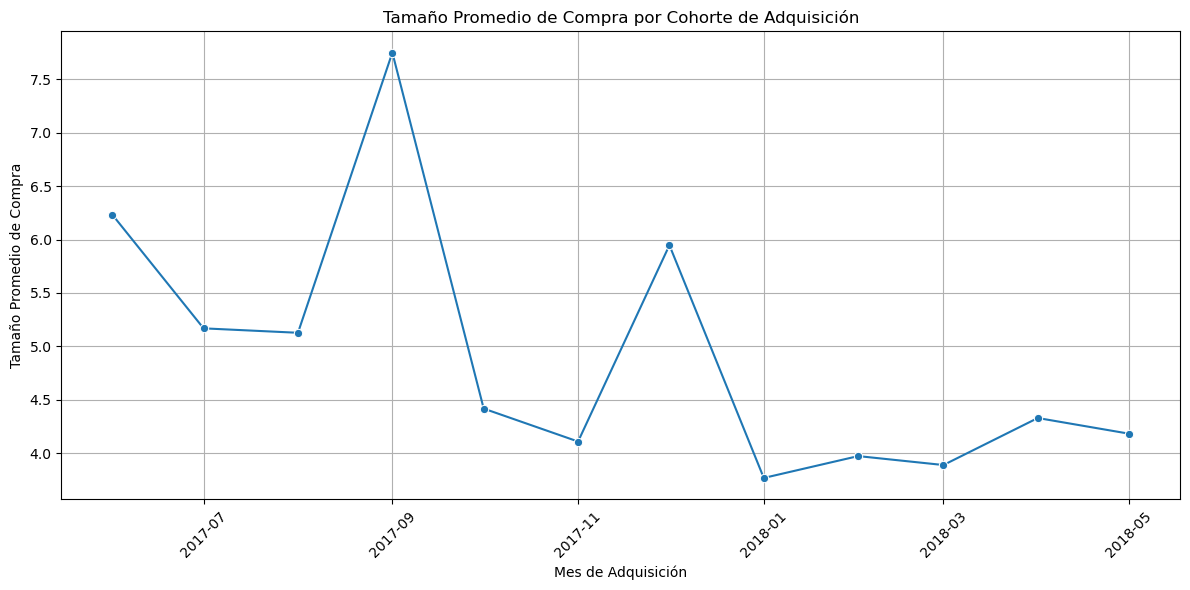

In [29]:
# Se procede a realizar el calculo:

average_purchase_size = df_orders_cohort.groupby('acquisition_month')['revenue'].mean().reset_index()
average_purchase_size.rename(columns={'revenue': 'average_purchase_size'}, inplace=True)

# Se procede a convertir 'acquisition_month' periodo[M]:
average_purchase_size['acquisition_month_datetime'] = average_purchase_size['acquisition_month'].dt.to_timestamp()

# Se imprime una muestra:

print('Tamaño promedio de compra por cohorte de adquisición:')
print(average_purchase_size.head())

# Se procede a graficar el resultado:

plt.figure(figsize=(12, 6))
sns.lineplot(data=average_purchase_size, x='acquisition_month_datetime', y='average_purchase_size', marker='o')
plt.title('Tamaño Promedio de Compra por Cohorte de Adquisición')
plt.xlabel('Mes de Adquisición')
plt.ylabel('Tamaño Promedio de Compra')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3.2.3 ¿Cuánto dinero traen? (LTV)



#### 3.2.3.1 Tabla Pivote: Ingresos por Cohorte y Tiempo

[Se procede a crear una tabla pivote que muestre la suma de ingresos por cohorte de adquisición y por el 'tiempo de vida']

Los pasos que se realizaran para crear la tabla dinámica son los siguientes:

1. Se agrupara el DataFrame 'df_orders_cohort' por 'acquisition_month' y 'cohort_lifetime'.

2. Se sumara los 'ingresos', se desapilara 'cohort_lifetime' en columnas, cmabiando cualquier vaor nulo con 0.

In [30]:
# Se procede a agrupar el df_orders_cohort por acquisition_month y cohort_lifetime, y calcular la suma de revenue

cohort_revenue = df_orders_cohort.groupby(['acquisition_month', 'cohort_lifetime']).agg({'revenue': 'sum'})

# Se procede a utilizar el método .unstack('cohort_lifetime') para transformar los 'tiempos de vida' de la cohorte en columnas

pivot_table_revenue = cohort_revenue.unstack('cohort_lifetime')

# Se procede a rellenar cualquier valor nulo (NaN) en la tabla pivote con 0

pivot_table_revenue = pivot_table_revenue.fillna(0)

# Se procede a mostrar la tabla pivote resultante
print('Tabla Pivote: Ingresos por Cohorte de Adquisición y Tiempo de Vida:')
print(' ')
print(' ')
print(pivot_table_revenue.head())


Tabla Pivote: Ingresos por Cohorte de Adquisición y Tiempo de Vida:
 
 
                    revenue                                                \
cohort_lifetime          0        1        2         3        4        5    
acquisition_month                                                           
2017-06             9294.81  2547.64  1347.50   3459.76  3469.60  2556.61   
2017-07             9829.58  1049.94  1088.07   1152.61   934.80   779.14   
2017-08             6109.17   990.63  1013.10    860.43   798.27   499.63   
2017-09            12126.60  3596.55  2017.07  10433.11  1281.85  1885.42   
2017-10            18150.07  3542.01  1235.55   1011.60   907.37   841.24   

                                                                         
cohort_lifetime         6        7        8        9        10       11  
acquisition_month                                                        
2017-06            3250.22  2056.51  2144.36  3317.40  2074.78  1444.07  
2017-07        

[Para normalizar los datos de ingresos y calcular el LTV, es fundamental determinar primero el número de usuarios únicos en cada cohorte de adquisición. Así se podra calcular el ingreso promedio por usuario para cada cohorte a lo largo de su vida útil.]

In [31]:
# Se procede a realizar el calculo:

cohort_sizes = first_order_date_by_customers.groupby('acquisition_month').agg({'uid': 'nunique'})
cohort_sizes.rename(columns={'uid': 'n_buyers'}, inplace=True)

# Se imprime el tamañode cada cohorte de adquisición:

print('Tamaño de cada cohorte de adquisición:')
print(cohort_sizes.head())

Tamaño de cada cohorte de adquisición:
                   n_buyers
acquisition_month          
2017-06                2789
2017-07                2388
2017-08                1664
2017-09                2995
2017-10                4584


[Con los ingresos totales por cohorte a lo largo del tiempo (pivot_table_revenue) y el tamaño de cada cohorte de adquisición (cohort_sizes), el siguiente paso es calcular el valor de vida útil (LTV) normalizando los ingresos por la cantidad de compradores únicos en cada cohorte.]

In [32]:
# Se procede a realizar el calculo:

ltv_cohorts = pivot_table_revenue.div(cohort_sizes['n_buyers'], axis=0)

# Se imprime el resultado:

print('Lifetime Value (LTV) por Cohorte de Adquisición y Tiempo de Vida:')
print(ltv_cohorts.head())

Lifetime Value (LTV) por Cohorte de Adquisición y Tiempo de Vida:
                    revenue                                                    \
cohort_lifetime          0         1         2         3         4         5    
acquisition_month                                                               
2017-06            3.332668  0.913460  0.483148  1.240502  1.244030  0.916676   
2017-07            4.116240  0.439673  0.455641  0.482668  0.391457  0.326273   
2017-08            3.671376  0.595331  0.608834  0.517085  0.479730  0.300258   
2017-09            4.048948  1.200851  0.673479  3.483509  0.427997  0.629523   
2017-10            3.959439  0.772690  0.269535  0.220681  0.197943  0.183517   

                                                                               
cohort_lifetime          6         7         8         9         10        11  
acquisition_month                                                              
2017-06            1.165371  0.737365  0.7688

[Se procede a trasladar lo realizado a un mapa de calor para una mejor visualización y comprensión de los datos]

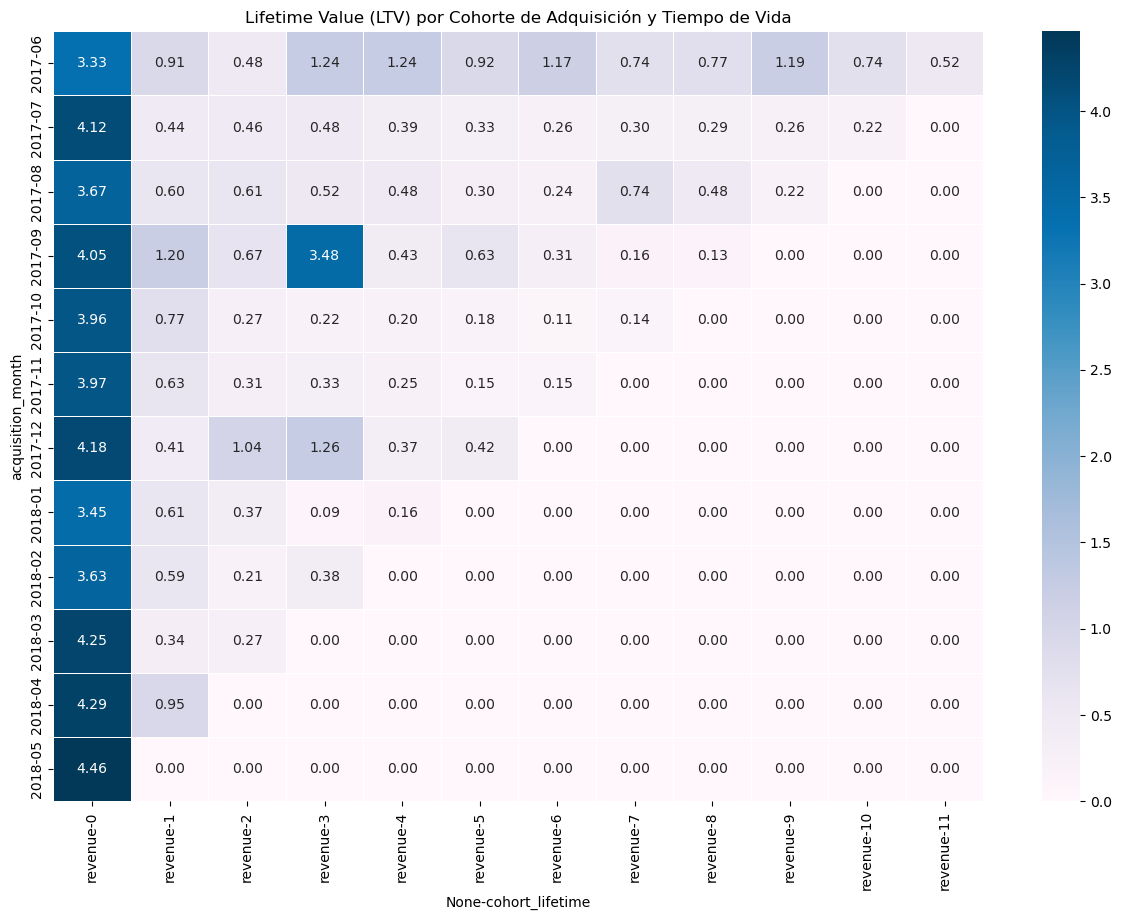

In [33]:
plt.figure(figsize=(15, 10))
plt.title('Lifetime Value (LTV) por Cohorte de Adquisición y Tiempo de Vida')
plt.xlabel('Tiempo de Vida de la Cohorte (Meses)')
plt.ylabel('Mes de Adquisición')
sns.heatmap(ltv_cohorts.iloc[:, :12],
            annot=True,
            fmt='.2f',
            linewidths=.5,
            cmap='PuBu',
            )
plt.show()

### 3.2.4 Conclusiones del punto 3.2 Ventas

Este punto del proyecto, el apartado "ventas" tuvo como fin identificar patrones de ingresos y pedidos por cohorte de adquisición, extraer el comportamiento del usuario a lo largo de su ciclo de vida y analizarlo.

A Continuación sesegmentara en los puntos mas relevantes:

1. Patrones de ingresos por cohorte de Adquisición:

* En el mapa de calor del LTV se mostro el comportamiento y la evolución del usuario en cuanto a los ingresos que se generan a lo largo del tiempo. Generalmente el LTV tiende a ser mas al en el mes de primeracompra, y este disminuye cradualmente con el tiempo. Los Cohortes mas recientes muestran curvaturas difernetes a pas anteriores, por tal motivo esto se podría interpretar que durante los ultimos cohortes los usuarios tuvieron una percepción de valor diferente con respecto a la interacción de los productos.

2. Patrones del numero de pedidos por cohorte de adquisición:

* Algo muy particular que se pudo apreciar en el comportamiento de los usuarios fue en la conversión que hubo entre el lapso de tiempo de las primeras visitas con relación a los primeros pedidos, en el descubrimientos se detecto que hay una mayor conversión de pedidos en una etapa muy temprana en cuanto a la interaccion con el sitio, y, posteior a realizar los primeros pedidos estos suelen disminuir gradualmente, en algunos casos de manera estrepitosa, por tal motivo se podría llegar a analizar la alternativa de apostar por una estrategía de marketing basada en crear fidelidad para lograr así una constante a lo largo del tiempo y no limitarse unicamente a obtener ingresos de las primeras ventas y luego perder al cliente con el tiempo.

3. Conclusiones sobre el comportamiento del usuario:

* Participación temprana: El patrón de los usuarios al momento es la generación de la mayor cantidad de ingresos casí de manera inmediata despues de interactuar con el sitio, paulatinamente estos se ven disminuidos

* Retos de retención: Tanto la retención de usuarios como el numero de pedidos tienden a disminuir drasticamente despues del mes de adquisición inicial. Por lo cual se tiene que someter a un analisís sobre la campaña de marketing que se esta utilizando, junto con la calidad del producto ofertado y la atención al cliente.

* Rendimiento variable de las cohortes de adquisición: Hay una cierta diferencia en los patrones de comportamiento de los usuarios a lo largo de los cohortes, estos influyen de manera significativa en el valor y comportamiento de los usuarios a largo plazo, por tal motivo se tiene que analizar la estrategia de marketing en cuanto a la estacionalidad o los cambios en la calidad del producto.

* Tamaño promedio de compra: En un principio los tamaños promedio de compra mostraban numeros bastantes relevantes, sin embargo, a lo largo del tiempo estos se vieron afectados y mostraron una tendencía a la baja, lo cual es preocupante por el tema de los ingresos. Así que, se tiene que analizar que fue lo que cambio entre las actividades realizadas antes y que se dejo de hacer para poder identificar el motivo por el cual se vio esta tendencía a la baja.


## 3.3 Marketing



Los objetivos a calcular son los siguientes:

1. ¿Cuánto dinero se gastó?  (Total/por fuente de adquisición/a lo largo del tiempo)
2. ¿Cuál fue el costo de adquisición de clientes de cada una de las fuentes?
3. ¿Cuán rentables eran las inversiones? (ROMI)

Traza gráficos para mostrar cómo difieren estas métricas para varios dispositivos y fuentes de anuncios y cómo cambian con el tiempo.

### 3.3.1 ¿Cuanto dinero se gasto?

[Se procede a realizar el calculo sobre el total, por fuente de adquisición y a lo largo del tiempo]

Se calculara el Gasto Total de Marketing: Se estara sumando la columna "costs" del DF 'df_gastos_marketing' para obtener el gasto total de Marketing durante todo el periodo de tiempo. Para tener una mejor visualización de los datos, se hara el calculo de manera anual

In [34]:
# Se procede a segmentar los gastos de Marketing por año en un nuevo DF llamad "df_gastos_marketing_anual" en la cual se estara incluyendo las columnas 'source_id, 'dt' y costs

df_gastos_marketing_anual = df_gastos_marketing.groupby([df_gastos_marketing['dt'].dt.year, 'source_id'])['costs'].sum().reset_index()

# Se procede a mostrar los datos del DF

print('\nInformación del DataFrame df_gastos_marketing_anual:')
df_gastos_marketing_anual.info()
print(' ')
print(' ')
print('----------------------')
print(' ')
print(' ')
print('Filas del DataFrame df_gastos_marketing_anual:')
print(df_gastos_marketing_anual.head(14))


Información del DataFrame df_gastos_marketing_anual:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   dt         14 non-null     int32  
 1   source_id  14 non-null     int64  
 2   costs      14 non-null     float64
dtypes: float64(1), int32(1), int64(1)
memory usage: 412.0 bytes
 
 
----------------------
 
 
Filas del DataFrame df_gastos_marketing_anual:
      dt  source_id     costs
0   2017          1  11754.42
1   2017          2  24547.68
2   2017          3  80495.21
3   2017          4  34944.28
4   2017          5  29613.94
5   2017          9   3202.88
6   2017         10   3402.74
7   2018          1   9078.85
8   2018          2  18258.36
9   2018          3  60826.42
10  2018          4  26129.32
11  2018          5  22143.16
12  2018          9   2314.61
13  2018         10   2419.75


[Se procede a sumar de manera anual los gastos de Marketing para saber cuanto fue el gasto total de Marketing de forma anual:]

In [35]:
# Se crea la variable 'total_marketing_cost_2017' y se sumara unicamente el costo total de marketing que corresponde al año 2017

total_marketing_cost_2017 = df_gastos_marketing_anual[df_gastos_marketing_anual['dt'] == 2017]['costs'].sum()

# Se crea la variable 'total_marketing_cost_2018' y se sumara unicamente el costo total de marketing que corresponde al año 2017

total_marketing_cost_2018 = df_gastos_marketing_anual[df_gastos_marketing_anual['dt'] == 2018]['costs'].sum()

# Se procede a imprimir los resultados:

print('El gasto total de Marketing en el 2017 fue el siguiente:', total_marketing_cost_2017)
print(' ')
print(' ')
print('----------------------')
print(' ')
print(' ')
print('El gasto total de Marketing en el 2018 fue el siguiente:', total_marketing_cost_2018)

El gasto total de Marketing en el 2017 fue el siguiente: 187961.15
 
 
----------------------
 
 
El gasto total de Marketing en el 2018 fue el siguiente: 141170.47


[Se calculara el Gasto de Marketing por fuente de adquisición:]

Se estara agrupando el DF 'df_gastos_marketing' por la columna "source_id" y se sumaran los costos para cada fuente, mostrando cuanto se gasto en cada canal.

In [36]:
# Se procede a agrupar el DF 'df_gastos_marketing' por medio de la columna "source_id" y se sumaran los gastos por canal:

gastos_por_fuente = df_gastos_marketing.groupby('source_id')['costs'].sum()

# Se procede a mostrar los datos:

print('\nInformación del DataFrame gastos_por_fuente:')
gastos_por_fuente.info()
print(' ')
print(' ')
print('----------------------')
print(' ')
print(' ')
print('Filas del DataFrame gastos_por_fuente:')
print(gastos_por_fuente.head(14))


Información del DataFrame gastos_por_fuente:
<class 'pandas.core.series.Series'>
Index: 7 entries, 1 to 10
Series name: costs
Non-Null Count  Dtype  
--------------  -----  
7 non-null      float64
dtypes: float64(1)
memory usage: 112.0 bytes
 
 
----------------------
 
 
Filas del DataFrame gastos_por_fuente:
source_id
1      20833.27
2      42806.04
3     141321.63
4      61073.60
5      51757.10
9       5517.49
10      5822.49
Name: costs, dtype: float64


Se calculara el gasto de Marketing a lo Largo del Tiempo (de manera mensual): Se procedera a crear un histograma que muestre como el gasto de Marketing cambia mes a mes, lo que nos ayudara a identificar las tendencias o estacionalidad.

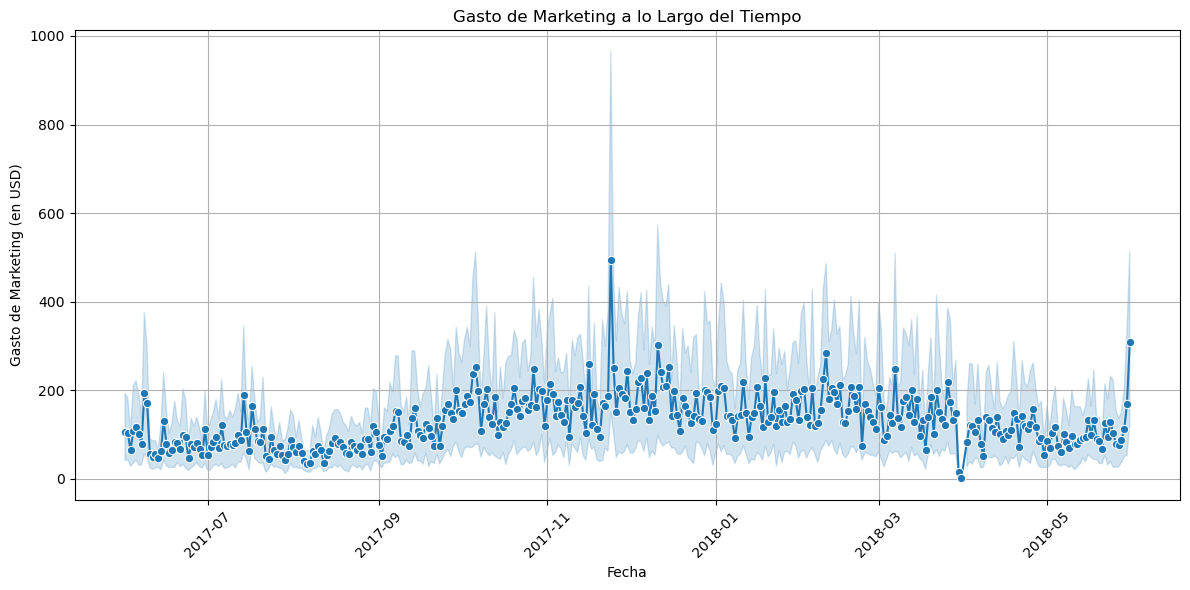

In [37]:
# Se procede a generar un grafico de lineas donde se muestre agrupado el total de gastos de marketing de forma mensual a lo largo del tiempo del DF "df_gastos_marketing"

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_gastos_marketing, x='dt', y='costs', marker='o')
plt.title('Gasto de Marketing a lo Largo del Tiempo')
plt.xlabel('Fecha')
plt.ylabel('Gasto de Marketing (en USD)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Visualizar Gasto de Marketing por fuente: Se procedera a generar un grafico de barras para comparar visualmente el gastototal de marketnig de cada fuente de adquisición

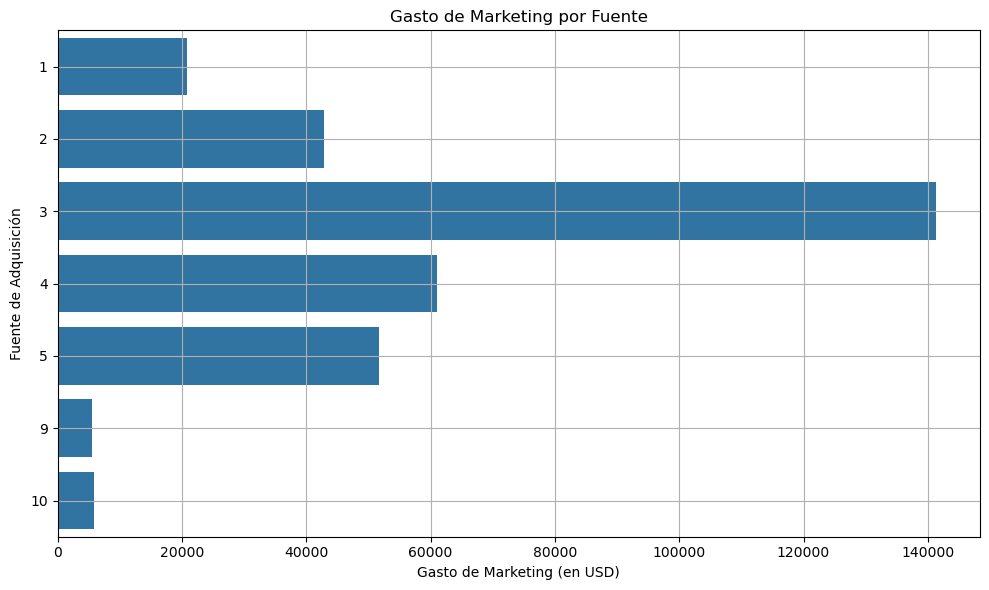

In [38]:
# Se procede a crear un grafico de barras donde se visualize el gasto total de marketing de cada fuente de adquisición

plt.figure(figsize=(10, 6))
gastos_por_fuente = df_gastos_marketing.groupby('source_id')['costs'].sum()
sns.barplot(x=gastos_por_fuente,
            y = gastos_por_fuente.index,
            orient='h')
plt.title('Gasto de Marketing por Fuente')
plt.xlabel('Gasto de Marketing (en USD)')
plt.ylabel('Fuente de Adquisición')
plt.tight_layout()
plt.grid(True)
plt.show()

### 3.3.2 ¿Cuál fue el costo de adquisición de clientes de cada una de las fuentes?

[Se procede a calcular el CAC]

Se creara un DF que permit identificar la primera fecha de visita de cada usuario.

In [39]:
# Se crea el DF "df_primera_fuente_de_adquisicion" donde se estara ingresando los datos de las columna "uid", "start_ts" y "source_id" a partir del DF "df_visitas_web"

df_primera_fuente_de_adquisicion = df_visitas_web[['uid', 'start_ts', 'source_id']]

# Se procede a mostrar la info del nuevo DF

print('\nInformación del DataFrame df_primera_fuente_de_adquisicion:')
df_primera_fuente_de_adquisicion.info()
print(' ')
print(' ')
print('----------------------')
print(' ')
print(' ')

# Se procede a mostrar las primeras lineas

print('Filas del DataFrame df_primera_fuente_de_adquisicion:')
print(df_primera_fuente_de_adquisicion.head())



Información del DataFrame df_primera_fuente_de_adquisicion:
<class 'pandas.core.frame.DataFrame'>
Index: 323604 entries, 0 to 359399
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   uid        323604 non-null  uint64        
 1   start_ts   323604 non-null  datetime64[ns]
 2   source_id  323604 non-null  int64         
dtypes: datetime64[ns](1), int64(1), uint64(1)
memory usage: 9.9 MB
 
 
----------------------
 
 
Filas del DataFrame df_primera_fuente_de_adquisicion:
                    uid            start_ts  source_id
0  16879256277535980062 2017-12-20 17:20:00          4
1    104060357244891740 2018-02-19 16:53:00          2
3  16174680259334210214 2018-05-20 10:59:00          9
5  16007536194108375387 2017-09-03 21:35:00          5
6   6661610529277171451 2018-01-30 11:13:00          1


[Se procede a contar loc clientes unicos por fuente de adquisición]

In [40]:
# Se agrupa el DF "df_primera_fuente_de_adquisicion" por la columna "source_id" y se contara el numero de "uid" unicos en cada grupo para obtener la cantidad de clientes unicos por cada fuente almacenando todo en la variable "clientes_unicos_por_fuente"

clientes_unicos_por_fuente = df_primera_fuente_de_adquisicion.groupby('source_id')['uid'].nunique()

# Se imprime la variable para visualizar la información:

print('\nCantidad de clientes únicos por fuente de adquisición:')
print(clientes_unicos_por_fuente)


Cantidad de clientes únicos por fuente de adquisición:
source_id
1     17960
2     24152
3     67284
4     75080
5     50921
6         5
7        33
9      8504
10     7208
Name: uid, dtype: int64


[Se Procede a realizar el CAC por fuente y posterior a ello se procede a reazliar un grafico de barras para su visualización:]


Costo de Adquisición por Fuente:
source_id
1     0.862083
2     0.564219
3     0.476105
4     1.229336
5     0.983846
6          NaN
7          NaN
9     1.541281
10    1.237958
dtype: float64
 
 
----------------------
 
 


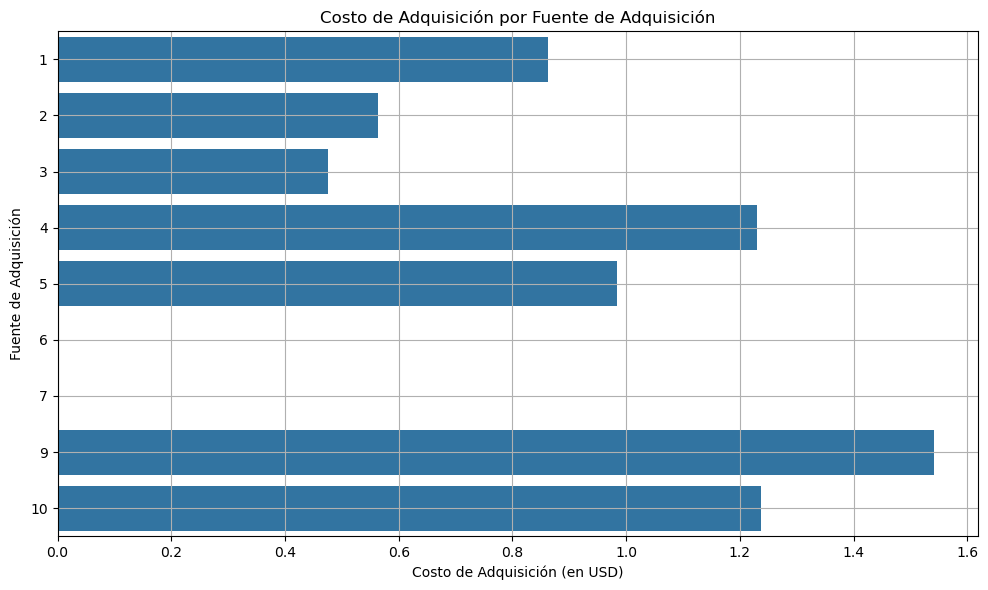

In [41]:
#Se procede a realizar el CAC por fuente almacenandolo en la variable cac_por_fuente

cac_por_fuente = clientes_unicos_por_fuente / gastos_por_fuente

#Se visuzaliza el resultado

print('\nCosto de Adquisición por Fuente:')
print(cac_por_fuente)
print(' ')
print(' ')
print('----------------------')
print(' ')
print(' ')

# Se genera el grafico de barras horizontales para visualizar el resultado

plt.figure(figsize=(10, 6))
cac_por_fuente = clientes_unicos_por_fuente / gastos_por_fuente
sns.barplot(x=cac_por_fuente,
            y=cac_por_fuente.index,
            orient='h')
plt.title('Costo de Adquisición por Fuente de Adquisición')
plt.xlabel('Costo de Adquisición (en USD)')
plt.ylabel('Fuente de Adquisición')
plt.tight_layout()
plt.grid(True)
plt.show()

### 3.3.3 ¿Cuán rentables eran las inversiones? (ROMI)

[Se Procedera a calcular los ingresos totales por fuentes de adquisición fusionando el DF "df_pedidos" con "df_primera_fuente_de_adquisición":]

In [42]:
# Se procede a fusionar los DF "df_pedidos" con "df_primera_fuente_de_adquisicion" por medio de uid

df_ingresos_por_fuente = df_pedidos.merge(df_primera_fuente_de_adquisicion, on='uid')

# Se procede a revisar la info resultante y mostrar las primeros 5 filas:

print('\nInformación del DataFrame df_ingresos_por_fuente:')
df_ingresos_por_fuente.info()
print(' ')
print(' ')
print('----------------------')
print(' ')
print(' ')
print('Filas del DataFrame df_ingresos_por_fuente:')
print(df_ingresos_por_fuente.head(5))


Información del DataFrame df_ingresos_por_fuente:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 721874 entries, 0 to 721873
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   buy_ts     721874 non-null  datetime64[ns]
 1   revenue    721874 non-null  float64       
 2   uid        721874 non-null  uint64        
 3   start_ts   721874 non-null  datetime64[ns]
 4   source_id  721874 non-null  int64         
dtypes: datetime64[ns](2), float64(1), int64(1), uint64(1)
memory usage: 27.5 MB
 
 
----------------------
 
 
Filas del DataFrame df_ingresos_por_fuente:
               buy_ts  revenue                   uid            start_ts  \
0 2017-06-01 00:10:00    17.00  10329302124590727494 2017-06-01 00:09:00   
1 2017-06-01 00:25:00     0.55  11627257723692907447 2017-06-01 00:14:00   
2 2017-06-01 00:27:00     0.37  17903680561304213844 2017-06-01 00:25:00   
3 2017-06-01 00:29:00     0.55  16109239769

[Se agrupan los ingresos para obtener el total de los ingresos generados por cada fuente:]

In [43]:
# Se crea una nueva variable llamada "ingresos_totales_por_fuentes" donde se agrupara la columna "revenue" del nuevo df por "source_id" para calcular el total de los ingresos generado por cada fuente

ingresos_totales_por_fuentes = df_ingresos_por_fuente.groupby('source_id')['revenue'].sum()

# Se imprime la variable "ingresos_totales_por_fuentes"

print('\nLos ingresos totales por fuente de adquisición:')
print(ingresos_totales_por_fuentes)


Los ingresos totales por fuente de adquisición:
source_id
1     2186798.00
2     2537589.34
3      277423.75
4      450379.35
5     1091968.00
7           1.22
9       33342.00
10      13584.12
Name: revenue, dtype: float64


[Con todas las variables necesarias obtenidas, se procede a realizar el calculo del ROMI y posterior a ello se generara un grafico de barras donde se visualice el ROMI por fuente de adquisición obtenida]


El ROMI por fuente de adquisición:
source_id
1     103.966623
2      58.281105
3       0.963066
4       6.374370
5      20.097936
7            NaN
9       5.042965
10      1.333043
dtype: float64
 
 
----------------------
 
 


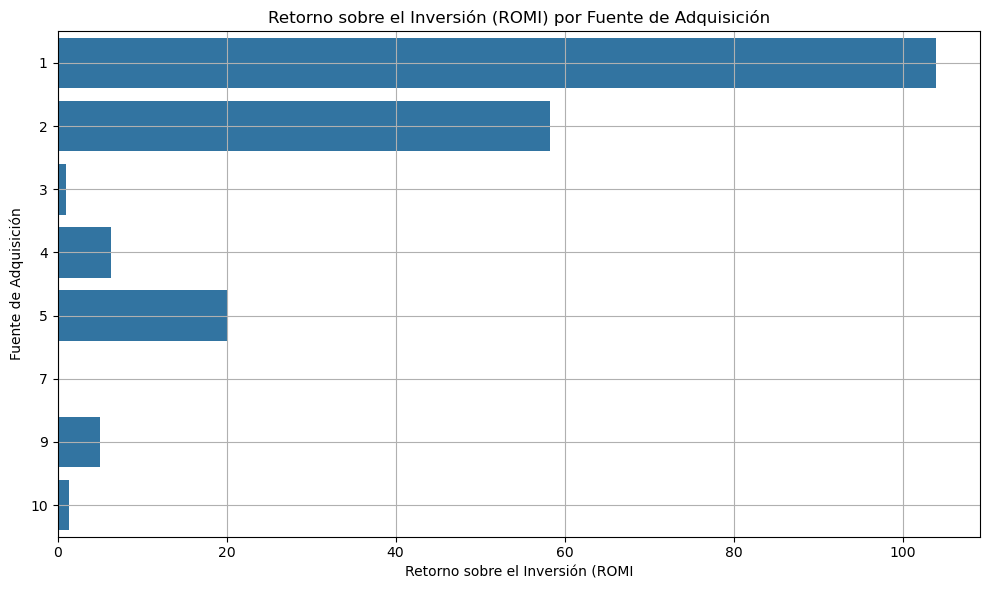

In [44]:
# Se procede a realizar el calculo del ROMI

romi = (ingresos_totales_por_fuentes - gastos_por_fuente) / gastos_por_fuente

# Se procede a imprimir el ROMI

print('\nEl ROMI por fuente de adquisición:')
print(romi)
print(' ')
print(' ')
print('----------------------')
print(' ')
print(' ')

# se procede a graficar el ROMI en una grafica de barras horizontales para la visualización de la misma:

plt.figure(figsize=(10, 6))
sns.barplot(x=romi,
            y=romi.index,
            orient='h')
plt.title('Retorno sobre el Inversión (ROMI) por Fuente de Adquisición')
plt.xlabel('Retorno sobre el Inversión (ROMI')
plt.ylabel('Fuente de Adquisición')
plt.tight_layout()
plt.grid(True)
plt.show()

### 3.3.4 Conclusiones de Marketing

Como se puede apreciar, al comparar todas las fuentes de Marketing, se pueden determinar los siguientes datos:

* Fuente que representa el mayor gasto global

Al analizar las fuentes que representan un mayor gasto en orden respectivamente para la organización son las siguientes:

    * 3
    * 4
    * 5

Mientras que las 3 fuentes que representan una inversión global menor para la organización son las siguientes:

    * 9
    * 10
    * 1

Para llegar a esta información se procedio a sumar el total de cada una de las fuentes y se genero un grafico de barras para una visualización mejor.

Estra metrica por si sola no es concluyente para obtener una vision clara sobre la rentabilidad de estas inversiones en especifico, así que para ello se procedera realizar el analisis de costo por adquisición en el siguiente punto.

-------------------------------

* Fuente que representa el mayor costo por adquisición

Al realizar un analisis sobre cuales fueron las fuentes que representan un CAC mayor para la organizacón en orden resoectivamente fueron las siguientes

      * 9
      * 10
      * 4

Y las descendentes:

      * 3
      * 2
      * 1

Esto nos indica que, a pesar de que el monto de inversion realizado en las fuentes 9 y 10 respectivamente es inferior a cualquier otra fuente, el costo para atraer mas clientes sobre estas fuentes es mucho mayor que las otras existentes.

Sin embargo, por otra parte, la fuente que hasta el momento con las metricas anteriores representa un mejor equilibrio con respecto en la relación que hay entre inversión realizada y el costo que representa en la atracción de nuevos clientes hasta el momento es la fuente 3, sin embargo los datos no son concluyentes hasta analizar el ROMI global obtenido por cada fuente.

---------------------------------------

* Fuente con mayor retorno de inversión

Al analziar la metrica mas relevante, la cual es el ROMI, nos podemos dar cuenta que las fuentes con mayor exito en cuanto a ingresos obtenidos son:

      * 1
      * 2

Sin embargo los que muestran los peores desempeños son:

      * 9
      * 10

Con estos datos podemos concluir que las fuentes con mejores resultados son la 1 y la 2, y los peores desempeños son la 9 y la 10

# 4.0 Conclusiones

[¿Qué fuentes/plataformas recomendarías?  Fundamenta tu selección: ¿en qué métricas te enfocaste?  ¿Por qué? ¿Qué conclusiones sacaste después de encontrar los valores métricos?]

## 4.1 Recapitulación de conclusiones por puntos:

### 4.1.1 Conclusiones de visitas:

Un punto relevante a resaltar es el patron de comportamiento del usuario, mas especificamente, el que esta relacionado con la retención de los usuarios.

Si bien el tiempo promedió en el que los usuarios se mantienen en el sitio es moderadamente alto (11 minutos), cabe resaltar que se esta teniendo un fallo en lograr que los usuarios regresen al sitio.

Mientras que a la semana el 15% de los usuarios vuelven a visitar la pagina, solo menos del 4% regresa en el mes. Por tal motivo se tiene que revisar mas adelante cual es la conversión de pedidos y la estrategía de marketing para poder determinar los accionables necesarios al momento ya sea de reconfigurar el sitio web, reconfigurar la estrategíade marketing o ver si va mas enfocado al tema de calidad del producto y atención al cliente.

### 4.1.2 Conclusiones de las ventas

Este punto del proyecto, el apartado "ventas" tuvo como fin identificar patrones de ingresos y pedidos por cohorte de adquisición, extraer el comportamiento del usuario a lo largo de su ciclo de vida y analizarlo.

A Continuación se segmentara en los puntos mas relevantes:

1. Patrones de ingresos por cohorte de Adquisición:

* En el mapa de calor del LTV se mostro el comportamiento y la evolución del usuario en cuanto a los ingresos que se generan a lo largo del tiempo. Generalmente el LTV tiende a ser mas alto en el mes de primera compra, y este disminuye gradualmente con el tiempo. Los Cohortes mas recientes muestran curvaturas difernetes a pas anteriores, por tal motivo esto se podría interpretar como que durante los ultimos cohortes los usuarios tuvieron una percepción de valor diferente con respecto a la interacción de los productos.

2. Patrones del numero de pedidos por cohorte de adquisición:

* Algo muy particular que se pudo apreciar en el comportamiento de los usuarios fue en la conversión que hubo entre el lapso de tiempo de las primeras visitas con relación a los primeros pedidos, en el descubrimientos se detecto que hay una mayor conversión de pedidos en una etapa muy temprana en cuanto a la interaccion con el sitio, y, posteior a realizar los primeros pedidos estos suelen disminuir gradualmente, en algunos casos de manera estrepitosa, por tal motivo se podría llegar a analizar la alternativa de apostar por una estrategía de marketing basada en crear fidelidad para lograr así una constante a lo largo del tiempo y no limitarse unicamente a obtener ingresos de las primeras ventas y luego perder al cliente con el tiempo.

3. Conclusiones sobre el comportamiento del usuario:

* Participación temprana: El patrón detectado en los usuarios es que la mayor cantidad de ingresos obtenidos se genera por usuarios que interactuan con el sitio por primera vez, paulatinamente estos se ven disminuidos

* Retos de retención: Tanto la retención de usuarios como el numero de pedidos tienden a disminuir drasticamente despues del mes de adquisición inicial. Por lo cual se tiene que someter a un analisís sobre la campaña de marketing que se esta utilizando, junto con la calidad del producto ofertado y la atención al cliente.

* Rendimiento variable de las cohortes de adquisición: Hay una cierta diferencia en los patrones de comportamiento de los usuarios a lo largo de los cohortes, estos influyen de manera significativa en el valor y comportamiento de los usuarios a largo plazo, por tal motivo se tiene que analizar la estrategia de marketing en cuanto a la estacionalidad o los cambios en la calidad del producto.

* Tamaño promedio de compra: En un principio los tamaños promedio de compra mostraban numeros bastantes relevantes, sin embargo, a lo largo del tiempo estos se vieron afectados y mostraron una tendencía a la baja, lo cual es preocupante por el tema de los ingresos. Así que, se tiene que analizar que fue lo que cambio entre las actividades realizadas antes y que se dejo de hacer para poder identificar el motivo por el cual se vio esta tendencía a la baja.


### 4.1.3 Conclusiones de Marketing



Como se puede apreciar, al comparar todas las fuentes de Marketing, se pueden determinar los siguientes datos:

* Fuente que representa el mayor gasto global

Al analizar las fuentes que representan un mayor gasto en orden respectivamente para la organización son las siguientes:

    * 3
    * 4
    * 5

Mientras que las 3 fuentes que representan una inversión global menor para la organización son las siguientes:

    * 9
    * 10
    * 1

Para llegar a esta información se procedio a sumar el total de cada una de las fuentes y se genero un grafico de barras para una visualización mejor.

Estra metrica por si sola no es concluyente para obtener una vision clara sobre la rentabilidad de estas inversiones en especifico, así que para ello se procedera realizar el analisis de costo por adquisición en el siguiente punto.

-------------------------------

* Fuente que representa el mayor costo por adquisición

Al realizar un analisis sobre cuales fueron las fuentes que representan un CAC mayor para la organizacón en orden resoectivamente fueron las siguientes

      * 9
      * 10
      * 4

Y las descendentes:

      * 3
      * 2
      * 1

Esto nos indica que, a pesar de que el monto de inversion realizado en las fuentes 9 y 10 respectivamente es inferior a cualquier otra fuente, el costo para atraer mas clientes sobre estas fuentes es mucho mayor que las otras existentes.

Sin embargo, por otra parte, la fuente que hasta el momento con las metricas anteriores representa un mejor equilibrio con respecto en la relación que hay entre inversión realizada y el costo que representa en la atracción de nuevos clientes hasta el momento es la fuente 3, sin embargo los datos no son concluyentes hasta analizar el ROMI global obtenido por cada fuente.

---------------------------------------

* Fuente con mayor retorno de inversión

Al analziar la metrica mas relevante, la cual es el ROMI, nos podemos dar cuenta que las fuentes con mayor exito en cuanto a ingresos obtenidos son:

      * 1
      * 2

Sin embargo los que muestran los peores desempeños son:

      * 9
      * 10

Con estos datos podemos concluir que las fuentes con mejores resultados son la 1 y la 2, y los peores desempeños son la 9 y la 10

## 4.2 Conclusiones finales

Dir. Planeación Estrategica
Dir. Marketing
Showz

Por medio del presente correo aprovecho para extenderle un cordial saludo, y así mismo para hacerle llegar mi reporte inicial sobre "Optimización de inversiones en el Departamento de Marketing", tal como se solicito en reuniones previas:

Al realizar un analisis exhaustivo sobre las metricas de visitias, ventas e inversiónes en fuentes de Marketing, se puede llegar a las siguientes conclusiones:

  1. Visitas:
  * Fallo en la retención de usuarios: Si bien el tiempo en el que los usuarios duran en el sitio es de 11 minutos, la tasa de retorno de usuarios a la semana es del 15%, sin embargo, al mes menos del 4% de los usuarios tienden a regrsar al sitio, lo cual es preocupante ya que, si se planea tener una mayor conversión de ventas en realción a los clientes existentes, se tiene que manejar ya sea una estretegía comercial mas agresiva para que los clientes que ya compraron una vez, vuelva a comprar mas veces, de la misma manera, se podría analizar con Marketing y finanzas la viabilidad para crear una especie de "membresía de fidelidad" para lograr que los usuarios regresen obteniendo una recompensa simbolica para una mayor satisfacción.

2. Ventas:

* Comportamiento de los usuarios:
    * Participación temprana: Al analizar las tasas de conversión y la perioricidad de tiempo de adquisición de la compra, se pudo detectar que los usuarios tienden a comprar mas facil y rapido en la o las primeras interacciónes con el sitio, posterior a ello se ve reducido estrepitosamente, por tal motivo, si el usuario no adquiere la primera compra durante la primera interacción con el sitio, a la semana se reduce a menos de un 20% de probabilidad en que los usuarios compren.
    * Retos de retención: Tal como se comento en el punto anterior, hay serios problemas de retención de usuarios, por tal motivo uno de los retos importantes en puerta es el de elaborar en el Departamento de Marketing una estrategía que permita tener una mayor conversión de entrada durante la primera intereacción como primer accionable, como segundo accionable, diseñar una campaña de fidelidad, descuentos o cupones, la cual persuada al usuario regresar a concluir su compra, adquirir la membresía, para tener un mayor compromiso con la marca y envíar cupones mediante correo electronico, para impulsar a los usuarios a volver, combinado con una campaña de recomendaciones, para que de esta manera se fomente la creación de una comunidad solida y logremos revertir las metricas de retención a la baja.
    * Tamaño de compra: En un principio se logro percibir un mayor ticket de compra en relación a la cantidad de usuarios, sin embargo, con el tiempo este fue reduciendose, lo cual nos puede indicar dos cosas 1) Marketing estaba haciendo algo bien que dejo de hacer. 2) El desempeño en cuanto a la atención que brinda el área comercial se ha visto afectado por algún motivo, por lo consiguiente se recomienda revisar los planes de trabajos anuales de cada uno de los respectivos equipo del 2017 y 2018 para determinar que fue lo que se dejo de hacer para así identificar el fallo e implementar estrategias simialres.

  3. Marketing:

  Al analizar la inversión total por fuente, el CAC y el ROMI se pudo detectar lo siguiente:

  * Las fuentes que generan un mayor rendimiento en relación a investión realizada y gastos de adquisición por cliente fueron las fuentes 1 y 2, por tal motivo, se recomienda incrementar el volumen de inversión en cada una de estas fuentes para así poder atraer un mayor volumen de clientes de calidad con un mayor rendimiento.
  * Las fuentes que generan un desempeño inferior o mediocre son las fuentes 9 y 10, cada una respectivamente representan un costo muy elevado al momento de convertirlos a ventas, si bien, la inversión realizada en comparación de otras campañas es inferior en comparación de otras fuentes, el costo de mantenimiento no representa un ROMI que pueda llegar a justificar su permanencía, por tal motivo se recomienda redirigir la inversión realizadas en estos a las fuentes 1 y 2.

En el cuerpo del Notebook adjunto en el presente correo se pueden encontrar la metodología utilizada para llegar a estas conclusiones, los graficos, las metricas y comentarios adicionales en caso de requererirse o ser necesarios.

Agradeciendo de antemano la atención y el tiempo brindados, quedo en pie y al orden al pendiente de sus comentarios.

Saludos!!

ATTE:

Data Analyst Sr.

Alfredo G Neri